In [1]:
import sys
!{sys.executable} -m pip install biopython pandas

In [21]:
from Bio import SeqIO, Entrez
from io import StringIO
import pandas as pd
import re

Entrez.email = "your_email@example.com"


def df_from_records(records):
    df = pd.DataFrame([{
        "ID": r.id,
        "Description": r.description,
        "Sequence": str(r.seq),
        "Length": len(r.seq)
    } for r in records])

    # Remove exact duplicate sequences, keep the first one
    df = df.drop_duplicates(subset="Sequence").reset_index(drop=True)

    return df


def norm(x):
    return re.sub(r"\s+", " ", x.strip().lower())


def ask_menu(prompt, options):
    while True:
        print("\n" + prompt)
        for i, op in enumerate(options, 1):
            print(f"{i}. {op}")
        x = input(f"Enter choice (1-{len(options)}): ").strip()
        if x.isdigit() and 1 <= int(x) <= len(options):
            return int(x) - 1
        print("Invalid choice. Please try again.")


def ask_positive_int(prompt):
    while True:
        x = input(prompt).strip()
        if x.isdigit() and int(x) > 0:
            return int(x)
        print("Please enter a whole number greater than 0.")


def ask_nonempty(prompt):
    while True:
        x = input(prompt).strip()
        if x:
            return x
        print("Input cannot be empty.")


def load_fasta():
    while True:
        path = ask_nonempty("Please enter the full path of your FASTA file: ")
        try:
            records = list(SeqIO.parse(path, "fasta"))
            if records:
                return records
            print("No sequences were found in that FASTA file.")
        except Exception as e:
            print(f"Could not read FASTA file: {e}")


ORG_HINTS = {
    "h1n1": "Influenza A virus",
    "influenza h1n1": "Influenza A virus",
    "flu h1n1": "Influenza A virus",
    "swine flu": "Influenza A virus",
    "covid": "Severe acute respiratory syndrome coronavirus 2",
    "covid 19": "Severe acute respiratory syndrome coronavirus 2",
    "covid-19": "Severe acute respiratory syndrome coronavirus 2",
    "sars cov 2": "Severe acute respiratory syndrome coronavirus 2",
    "sars-cov-2": "Severe acute respiratory syndrome coronavirus 2",
    "tb": "Mycobacterium tuberculosis",
    "e coli": "Escherichia coli",
    "mrsa": "Staphylococcus aureus",
}

GROUPS = {
    "Bacteria": {
        "examples": ["Escherichia coli", "Bacillus subtilis", "Mycobacterium tuberculosis"],
        "proteins": ["16S ribosomal protein", "dnaK", "gyrA", "rpoB"]
    },
    "Archaea": {
        "examples": ["Methanococcus maripaludis", "Methanosarcina barkeri", "Halobacterium salinarum"],
        "proteins": ["mcrA", "mcrB", "mcrG", "16S ribosomal protein"]
    },
    "Viruses": {
        "examples": ["Influenza A virus", "Severe acute respiratory syndrome coronavirus 2", "Human immunodeficiency virus 1"],
        "proteins": ["hemagglutinin", "neuraminidase", "nucleoprotein", "spike"]
    },
    "Fungi": {
        "examples": ["Saccharomyces cerevisiae", "Candida albicans", "Aspergillus fumigatus"],
        "proteins": ["beta-tubulin", "actin", "calmodulin"]
    },
    "Protozoa": {
        "examples": ["Plasmodium falciparum", "Trypanosoma brucei", "Giardia lamblia"],
        "proteins": ["actin", "tubulin", "18S ribosomal protein"]
    }
}


def suggest_organism(text):
    t = norm(text)
    if t in ORG_HINTS:
        return ORG_HINTS[t]
    if t in {"virus", "viruses", "bacteria", "archaea", "fungi", "protozoa", "microbe", "microbes"}:
        return None
    return text.strip()


def ask_exact_or_group():
    mode = ask_menu("How do you want to choose the microorganism?", [
        "I know the exact microorganism name",
        "Let me choose from groups"
    ])

    if mode == 0:
        while True:
            org = ask_nonempty("Enter microorganism name: ")
            s = suggest_organism(org)

            if s is None:
                print("That is too broad. Please enter a specific organism name or use group selection.")
                continue

            if s != org.strip():
                print(f"\nThat input is not the best exact organism name.")
                print(f"Did you mean: {s}")
                c = ask_menu("Choose one:", ["Yes, use this", "No, enter again", "Switch to group selection"])
                if c == 0:
                    return s, None
                if c == 1:
                    continue
                return ask_group_mode()

            return org.strip(), None

    return ask_group_mode()


def ask_group_mode():
    group = list(GROUPS.keys())[ask_menu("Choose microorganism group:", list(GROUPS.keys()))]
    ex = GROUPS[group]["examples"]
    choice = ask_menu(f"Choose an example organism from {group}, or type your own:", ex + ["Type my own organism name"])

    if choice < len(ex):
        return ex[choice], group

    while True:
        org = ask_nonempty("Enter microorganism name: ")
        s = suggest_organism(org)

        if s is None:
            print("That is too broad for an exact organism name.")
            continue

        if s != org.strip():
            print(f"\nDid you mean: {s}")
            c = ask_menu("Choose one:", ["Yes, use this", "No, enter again"])
            if c == 0:
                return s, group
            continue

        return org.strip(), group


def ask_protein(group, organism):
    mode = ask_menu("How do you want to choose the protein/gene?", [
        "Type the exact protein/gene name",
        "Choose from suggested options"
    ])

    suggestions = GROUPS[group]["proteins"] if group else ["mcrA", "16S ribosomal protein", "hemagglutinin", "spike"]

    if mode == 1:
        return suggestions[ask_menu("Choose a protein/gene:", suggestions)]

    while True:
        p = ask_nonempty("Enter protein/gene name: ")
        t = norm(p)

        if t in {"h1n1", "influenza h1n1", "flu", "virus"}:
            print("\nThat is not a protein/gene name.")
            print("For Influenza A virus, try one of these:")
            flu_ops = ["hemagglutinin", "neuraminidase", "nucleoprotein"]
            return flu_ops[ask_menu("Choose one:", flu_ops)]

        return p.strip()


def build_query(org, protein):
    return f'"{protein}" AND "{org}"[Organism]'


def fetch_ncbi(query, n):
    h = Entrez.esearch(db="protein", term=query, retmax=n)
    res = Entrez.read(h)
    h.close()

    ids = res.get("IdList", [])
    if not ids:
        return []

    h = Entrez.efetch(db="protein", id=",".join(ids), rettype="fasta", retmode="text")
    fasta = h.read()
    h.close()

    records = list(SeqIO.parse(StringIO(fasta), "fasta"))

    # Remove exact duplicate sequences before returning
    unique_records = []
    seen_sequences = set()

    for r in records:
        seq = str(r.seq)
        if seq not in seen_sequences:
            seen_sequences.add(seq)
            unique_records.append(r)

    return unique_records


def guided_ncbi():
    while True:
        level = ask_menu("Choose search mode:", ["Beginner", "Advanced"])

        if level == 0:
            org, group = ask_group_mode()
            protein = GROUPS[group]["proteins"][ask_menu("Choose a suggested protein/gene:", GROUPS[group]["proteins"])]
        else:
            org, group = ask_exact_or_group()
            protein = ask_protein(group, org)

        n = ask_positive_int("How many sequences do you want to download? ")

        print("\nPlease confirm:")
        print(f"Organism: {org}")
        print(f"Protein/Gene: {protein}")
        print(f"Number of sequences: {n}")

        c = ask_menu("Continue?", ["Yes, search NCBI", "No, start over"])
        if c == 1:
            continue

        query = build_query(org, protein)
        print(f"\nSearching NCBI with query: {query}")

        try:
            records = fetch_ncbi(query, n)
            if records:
                return records
            print("\nNo sequences were found.")
            print("Please try again with a different organism or protein/gene name.")
        except Exception as e:
            print(f"\nError while fetching from NCBI: {e}")
            print("Please try again.")


def main():
    choice = ask_menu("Choose input method:", [
        "Upload local FASTA file",
        "Download automatically from NCBI"
    ])

    records = load_fasta() if choice == 0 else guided_ncbi()

    protein_df = df_from_records(records)
    print(f"\nLoaded {len(protein_df)} unique sequences successfully.")
    print(protein_df.head())

    return protein_df


protein_df = main()


Choose input method:
1. Upload local FASTA file
2. Download automatically from NCBI


Enter choice (1-2):  1
Please enter the full path of your FASTA file:  /Users/mahdis/Downloads/sequence (combined).fasta


Could not read FASTA file: [Errno 1] Operation not permitted: '/Users/mahdis/Downloads/sequence (combined).fasta'


Please enter the full path of your FASTA file:  /Users/mahdis/Downloads/sequence (combined).fasta


Could not read FASTA file: [Errno 1] Operation not permitted: '/Users/mahdis/Downloads/sequence (combined).fasta'


...

Could not read FASTA file: [Errno 2] No such file or directory: '"/Users/mahdis/Downloads/sequence (3).fasta"'


Please enter the full path of your FASTA file:  /Users/mahdis/Downloads/sequence (3).fasta


Could not read FASTA file: [Errno 1] Operation not permitted: '/Users/mahdis/Downloads/sequence (3).fasta'


Please enter the full path of your FASTA file:  /Users/mahdis/Library/CloudStorage/OneDrive-UniversityofMiami/sequence (combined).fasta



Loaded 8 unique sequences successfully.
           ID                                        Description  \
0  ADC45737.1  ADC45737.1 nucleocapsid protein [Influenza A v...   
1  ADC45738.1  ADC45738.1 neuraminidase [Influenza A virus (A...   
2  ADC45736.1  ADC45736.1 hemagglutinin [Influenza A virus (A...   
3  ADC45735.1  ADC45735.1 polymerase PA [Influenza A virus (A...   
4  ACF48968.1  ACF48968.1 polymerase PB1, partial [Influenza ...   

                                            Sequence  Length  
0  MASQGTKRSYEQMETDGERQNATEIRASVGRMIGGIGRFYIQMCTE...     498  
1  MNPNQKIITIGSISIAIGIISLMLQIGNIISIWASHSIQTGSQNNT...     470  
2  MKVKLLVLLCTFTATYADTICIGYHANNSTDTVDTVLEKNVTVTHS...     565  
3  MEDFVRQCFNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...     716  
4  RTHQYSEKGKWTTNSETGAPQLNPIDGPLPEDNEPSGYAQTDCVLE...     713  


In [23]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio.SeqRecord import SeqRecord
import pandas as pd

VALID_AA = set("ACDEFGHIKLMNPQRSTVWY")

def calculate_properties(data):
    rows = []

    if isinstance(data, pd.DataFrame):
        source_data = data.to_dict(orient="records")
    else:
        source_data = data

    for item in source_data:
        if isinstance(item, SeqRecord):
            seq = str(item.seq).strip().upper()
            if not seq:
                continue

            rows.append({
                "ID": item.id,
                "Description": item.description,
                "Sequence": seq
            })

        elif isinstance(item, dict):
            seq = str(item.get("Sequence", "")).strip().upper()
            if not seq:
                continue

            rows.append({
                "ID": item.get("ID", "Unknown"),
                "Description": item.get("Description", ""),
                "Sequence": seq
            })

    results = []
    skipped = []

    for row in rows:
        seq = row["Sequence"]

        invalid_chars = set(seq) - VALID_AA
        if invalid_chars:
            skipped.append((row["ID"], "".join(sorted(invalid_chars))))
            continue

        analysis = ProteinAnalysis(seq)

        aa_percent = analysis.amino_acids_percent
        aa_composition = analysis.count_amino_acids()

        results.append({
            "ID": row["ID"],
            "Description": row["Description"],
            "Sequence": seq,
            "Length": len(seq),
            "Molecular_Weight": analysis.molecular_weight(),
            "Isoelectric_Point": analysis.isoelectric_point(),
            "Extinction_Coefficient_Reduced": analysis.molar_extinction_coefficient()[0],
            "Extinction_Coefficient_Oxidized": analysis.molar_extinction_coefficient()[1],
            "Aromaticity": analysis.aromaticity(),
            "Instability_Index": analysis.instability_index(),
            "Gravy": analysis.gravy(),
            "AA_Composition_Count": aa_composition,
            "AA_Composition_Percent": aa_percent
        })

    if skipped:
        print("Skipped sequences with invalid amino acid letters:")
        for seq_id, bad_chars in skipped:
            print(f"{seq_id}: {bad_chars}")

    return pd.DataFrame(results)

if "protein_df" in globals():
    properties_df = calculate_properties(protein_df)
elif "records" in globals():
    properties_df = calculate_properties(records)
else:
    raise NameError("Neither 'protein_df' nor 'records' exists. Run the FASTA upload/fetch cell first.")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print(properties_df)

# properties_df.to_csv("protein_properties.csv", index=False)
properties_df.to_excel("protein_properties.xlsx", index=False)

           ID                                        Description  \
0  ADC45737.1  ADC45737.1 nucleocapsid protein [Influenza A v...   
1  ADC45738.1  ADC45738.1 neuraminidase [Influenza A virus (A...   
2  ADC45736.1  ADC45736.1 hemagglutinin [Influenza A virus (A...   
3  ADC45735.1  ADC45735.1 polymerase PA [Influenza A virus (A...   
4  ACF48968.1  ACF48968.1 polymerase PB1, partial [Influenza ...   
5  ACF48967.1  ACF48967.1 polymerase PB2, partial [Influenza ...   
6  ACF48964.1  ACF48964.1 polymerase PB1, partial [Influenza ...   
7  ACF48963.1  ACF48963.1 polymerase PB2, partial [Influenza ...   

                                            Sequence  Length  \
0  MASQGTKRSYEQMETDGERQNATEIRASVGRMIGGIGRFYIQMCTE...     498   
1  MNPNQKIITIGSISIAIGIISLMLQIGNIISIWASHSIQTGSQNNT...     470   
2  MKVKLLVLLCTFTATYADTICIGYHANNSTDTVDTVLEKNVTVTHS...     565   
3  MEDFVRQCFNPMIVELAEKAMKEYGEDLKIETNKFAAICTHLEVCF...     716   
4  RTHQYSEKGKWTTNSETGAPQLNPIDGPLPEDNEPSGYAQTDCVLE...     713   
5  

In [25]:
from Bio import pairwise2
from Bio.SeqRecord import SeqRecord
import pandas as pd
import numpy as np

def calculate_pairwise_similarity(data):
    rows = []

    if isinstance(data, pd.DataFrame):
        source_data = data.to_dict(orient="records")
    else:
        source_data = data

    for item in source_data:
        if isinstance(item, SeqRecord):
            seq = str(item.seq).strip()
            if not seq:
                continue

            rows.append({
                "ID": item.id,
                "Sequence": seq
            })

        elif isinstance(item, dict):
            seq = str(item.get("Sequence", "")).strip()
            if not seq:
                continue

            rows.append({
                "ID": item.get("ID", "Unknown"),
                "Sequence": seq
            })

    ids = [row["ID"] for row in rows]
    sequences = [row["Sequence"] for row in rows]

    similarity_matrix = pd.DataFrame(
        np.zeros((len(ids), len(ids))),
        index=ids,
        columns=ids
    )

    for i in range(len(sequences)):
        for j in range(len(sequences)):
            seq1 = sequences[i]
            seq2 = sequences[j]

            alignment = pairwise2.align.globalxx(seq1, seq2, one_alignment_only=True)[0]
            matches = alignment.score
            max_len = max(len(seq1), len(seq2))
            similarity_percent = (matches / max_len) * 100

            similarity_matrix.iloc[i, j] = similarity_percent

    return similarity_matrix

# Automatically use whichever variable already exists
if "protein_df" in globals():
    similarity_df = calculate_pairwise_similarity(protein_df)
elif "records" in globals():
    similarity_df = calculate_pairwise_similarity(records)
else:
    raise NameError("Neither 'protein_df' nor 'records' exists. Run the FASTA upload/fetch cell first.")

print(similarity_df.round(2))
for i in range(len(protein_df)):
    for j in range(i + 1, len(protein_df)):
        same = protein_df.iloc[i]["Sequence"] == protein_df.iloc[j]["Sequence"]
        print(protein_df.iloc[i]["ID"], protein_df.iloc[j]["ID"], same)

            ADC45737.1  ADC45738.1  ADC45736.1  ADC45735.1  ACF48968.1  \
ADC45737.1      100.00       35.34       32.39       30.31       30.72   
ADC45738.1       35.34      100.00       32.92       28.91       28.61   
ADC45736.1       32.39       32.92      100.00       31.98       32.26   
ADC45735.1       30.31       28.91       31.98      100.00       37.01   
ACF48968.1       30.72       28.61       32.26       37.01      100.00   
ACF48967.1       30.31       27.24       30.44       36.05       35.91   
ACF48964.1       29.75       28.02       31.87       35.72       94.16   
ACF48963.1       30.17       27.24       30.44       36.32       35.78   

            ACF48967.1  ACF48964.1  ACF48963.1  
ADC45737.1       30.31       29.75       30.17  
ADC45738.1       27.24       28.02       27.24  
ADC45736.1       30.44       31.87       30.44  
ADC45735.1       36.05       35.72       36.32  
ACF48968.1       35.91       94.16       35.78  
ACF48967.1      100.00       36.52     

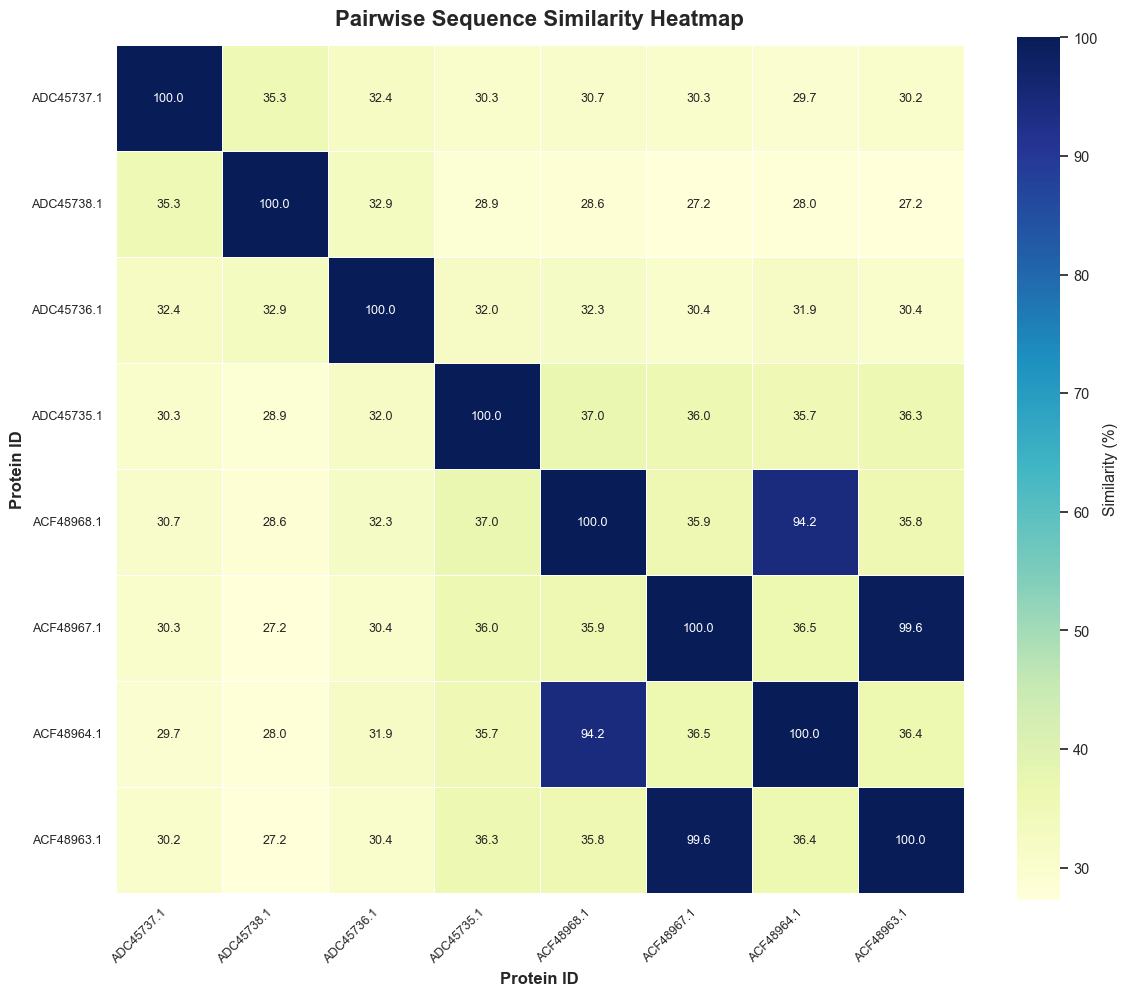

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# optional: make style nicer
sns.set_theme(style="white", font_scale=0.95)

plt.figure(figsize=(12, 10))

ax = sns.heatmap(
    similarity_df,
    annot=True,              # show numbers in cells
    fmt=".1f",               # 1 decimal place
    cmap="YlGnBu",           # prettier color map
    linewidths=0.5,          # lines between cells
    linecolor="white",
    square=True,             # make cells square
    cbar_kws={"label": "Similarity (%)"},
    annot_kws={"size": 9}
)

plt.title("Pairwise Sequence Similarity Heatmap", fontsize=16, weight="bold", pad=14)
plt.xlabel("Protein ID", fontsize=12, weight="bold")
plt.ylabel("Protein ID", fontsize=12, weight="bold")

plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

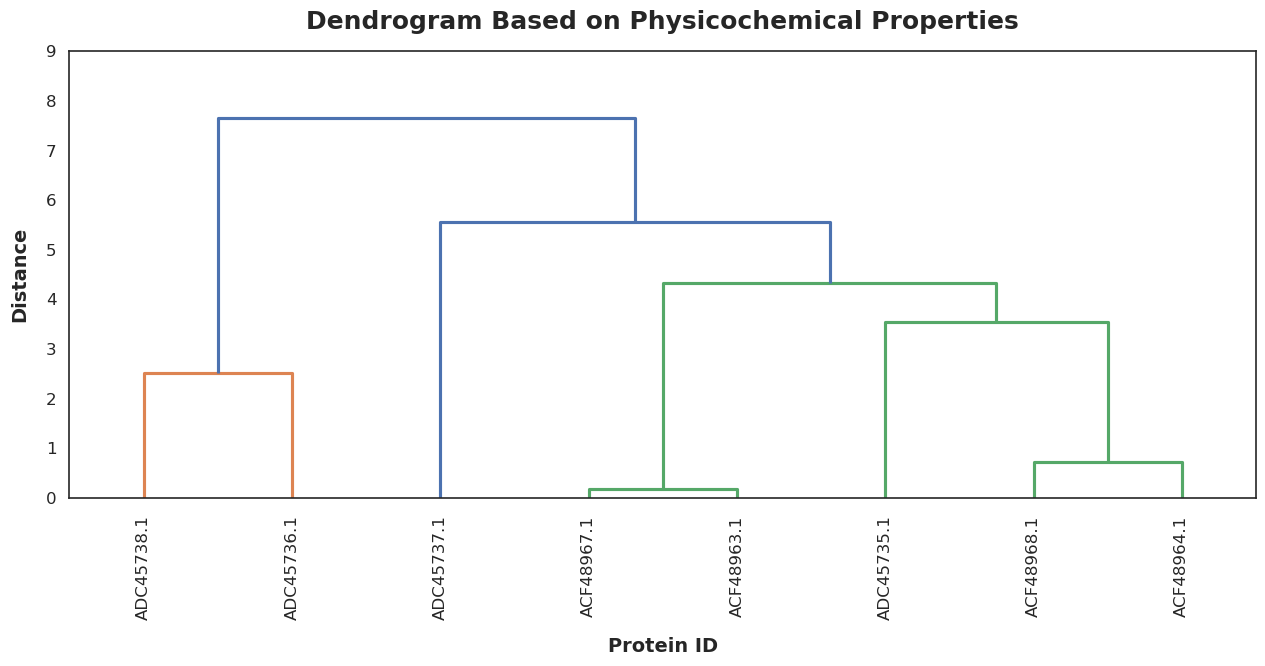

In [29]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import numpy as np

# Select physicochemical columns
physchem_data = properties_df[[
    "Length",
    "Molecular_Weight",
    "Isoelectric_Point",
    "Extinction_Coefficient_Reduced",
    "Extinction_Coefficient_Oxidized",
    "Aromaticity",
    "Instability_Index",
    "Gravy"
]]

# Standardize values
scaler = StandardScaler()
scaled_physchem = scaler.fit_transform(physchem_data)

# Cluster
linked_physchem = linkage(scaled_physchem, method="ward")

# Style
sns.set_theme(style="white", context="talk")
plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax = plt.subplots(figsize=(13, 7), facecolor="white")

dendrogram(
    linked_physchem,
    labels=properties_df["ID"].tolist(),
    leaf_rotation=90,
    leaf_font_size=12,
    ax=ax
)

ax.set_title(
    "Dendrogram Based on Physicochemical Properties",
    fontsize=18,
    weight="bold",
    pad=16
)
ax.set_xlabel("Protein ID", fontsize=14, weight="semibold", labelpad=12)
ax.set_ylabel("Distance", fontsize=14, weight="semibold", labelpad=12)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

ax.grid(False)

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12, length=6, width=1.2)

ymax = ax.get_ylim()[1]
ax.set_yticks(np.arange(0, ymax + 1, 1))

plt.tight_layout()
plt.show()

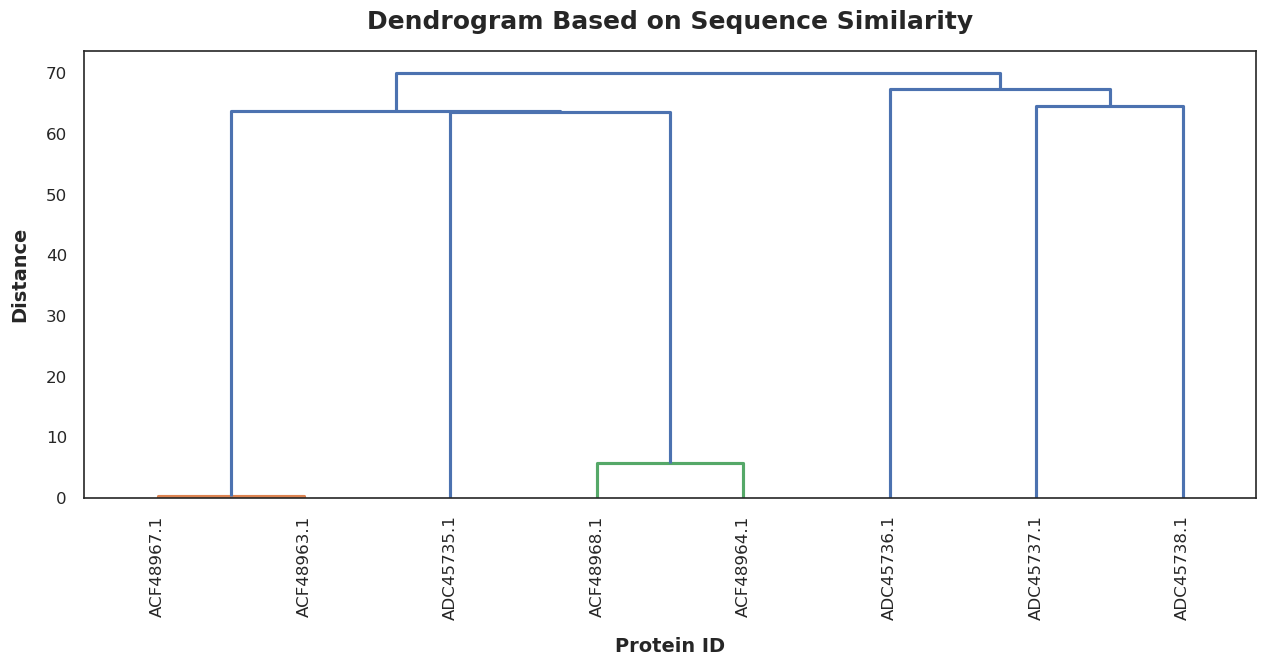

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# Convert similarity matrix to distance matrix
distance_df = 100 - similarity_df.copy()

# Set diagonal to zero
np.fill_diagonal(distance_df.values, 0)

# Convert to condensed distance format
condensed_distance = squareform(distance_df.values)

# Hierarchical clustering
linked_seq = linkage(condensed_distance, method="average")

# Style
sns.set_theme(style="white", context="talk")
plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax = plt.subplots(figsize=(13, 7), facecolor="white")

dendrogram(
    linked_seq,
    labels=similarity_df.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=12,
    ax=ax
)

# Titles and labels
ax.set_title(
    "Dendrogram Based on Sequence Similarity",
    fontsize=18,
    weight="bold",
    pad=16
)
ax.set_xlabel("Protein ID", fontsize=14, weight="semibold", labelpad=12)
ax.set_ylabel("Distance", fontsize=14, weight="semibold", labelpad=12)

# Keep full box around plot
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

# Remove grid
ax.grid(False)

# Tick styling
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.show()

Using these physicochemical columns:
['Length', 'Molecular_Weight', 'Isoelectric_Point', 'Extinction_Coefficient_Reduced', 'Extinction_Coefficient_Oxidized', 'Aromaticity', 'Instability_Index', 'Gravy']


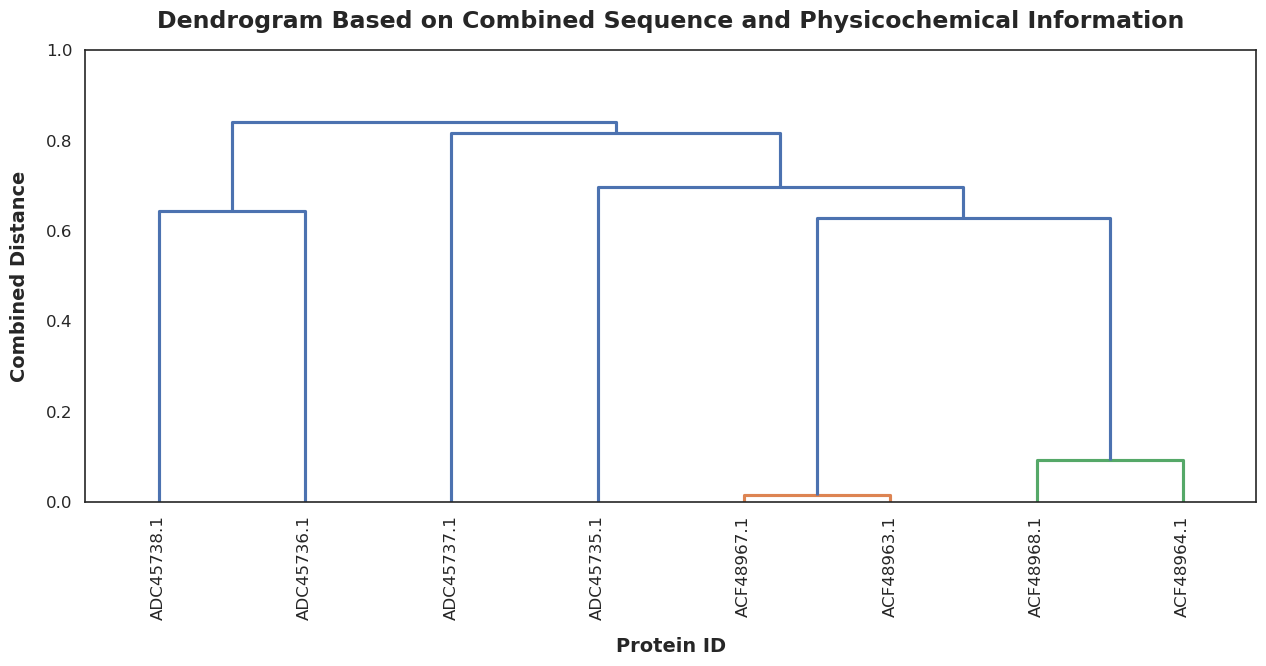

In [33]:
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Define the physicochemical properties you want
wanted_physchem_cols = [
    "Length",
    "Molecular_Weight",
    "Isoelectric_Point",
    "Net_Charge_pH_7",
    "Extinction_Coefficient_Reduced",
    "Extinction_Coefficient_Oxidized",
    "Aromaticity",
    "Instability_Index",
    "Gravy"
]

# 2. Keep only the columns that actually exist in properties_df
available_physchem_cols = [col for col in wanted_physchem_cols if col in properties_df.columns]

# Optional check
print("Using these physicochemical columns:")
print(available_physchem_cols)

if len(available_physchem_cols) == 0:
    raise ValueError("No valid physicochemical columns were found in properties_df.")

# 3. Select numeric physicochemical properties
physchem_data = properties_df[available_physchem_cols].copy()

# 4. Make sure all selected columns are numeric
physchem_data = physchem_data.apply(pd.to_numeric, errors="coerce")

# 5. Drop rows with missing values in selected columns
valid_mask = physchem_data.notna().all(axis=1)
physchem_data = physchem_data.loc[valid_mask].copy()

# Match IDs to the same filtered rows
filtered_ids = properties_df.loc[valid_mask, "ID"].tolist()

# 6. Standardize physicochemical data
scaler = StandardScaler()
scaled_physchem = scaler.fit_transform(physchem_data)

# 7. Compute physicochemical distance matrix
physchem_dist = squareform(pdist(scaled_physchem, metric="euclidean"))

# 8. Match sequence similarity matrix to the same filtered proteins
similarity_filtered = similarity_df.loc[filtered_ids, filtered_ids]

# 9. Compute sequence distance matrix
seq_dist = 100 - similarity_filtered.values
np.fill_diagonal(seq_dist, 0)

# 10. Standardize both distance matrices so one does not dominate
physchem_dist_scaled = physchem_dist / physchem_dist.max() if physchem_dist.max() != 0 else physchem_dist
seq_dist_scaled = seq_dist / seq_dist.max() if seq_dist.max() != 0 else seq_dist

# 11. Combine them equally
combined_dist = (physchem_dist_scaled + seq_dist_scaled) / 2

# 12. Convert to condensed form
combined_condensed = squareform(combined_dist)

# 13. Cluster
linked_combined = linkage(combined_condensed, method="average")

# 14. Style
sns.set_theme(style="white", context="talk")
plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax = plt.subplots(figsize=(13, 7), facecolor="white")

dendrogram(
    linked_combined,
    labels=filtered_ids,
    leaf_rotation=90,
    leaf_font_size=12,
    ax=ax
)

ax.set_title(
    "Dendrogram Based on Combined Sequence and Physicochemical Information",
    fontsize=17,
    weight="bold",
    pad=16
)
ax.set_xlabel("Protein ID", fontsize=14, weight="semibold", labelpad=12)
ax.set_ylabel("Combined Distance", fontsize=14, weight="semibold", labelpad=12)

# Box around plot
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)
ax.tick_params(axis="y", which="major", length=6, width=1.2, direction="out", labelsize=12)
ax.tick_params(axis="x", which="major", length=6, width=1.2, direction="out", labelsize=12)

# Optional: clearer y tick spacing
ymax = ax.get_ylim()[1]
ax.set_yticks(np.arange(0, ymax + 0.2, 0.2))

ax.grid(False)

plt.tight_layout()
plt.show()